In [1]:
import json

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator

sns.set_theme(style='whitegrid', palette='pastel')

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif='Charter')
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 300


In [2]:
with open('areas.json') as file:
    areas = json.load(file)

with open('../opsd/eu_countries.json') as file:
    eu_countries = json.load(file)

opsd = pd.read_csv('../opsd/opsd.csv', header=[0, 1], index_col=0)
opsd.index = pd.to_datetime(opsd.index)

In [3]:
countries = {}
for energy_target in eu_countries.keys():
    regions = np.unique([region for (region, target) in opsd.columns
                         if '_' not in region and target == energy_target])
    countries[energy_target] = {}
    for region in regions:
        energy_series = opsd.loc[:, (region, energy_target)]
        filter = np.where(~energy_series.isna())
        countries[energy_target][region] = {}
        countries[energy_target][region]['start'] = energy_series.index[filter[0][0]].strftime('%Y-%m-%d')
        countries[energy_target][region]['end'] = energy_series.index[filter[0][-1]].strftime('%Y-%m-%d')
        countries[energy_target][region]['missing_2015'] = energy_series.loc['2015'].isna().sum()
        countries[energy_target][region]['missing_2016'] = energy_series.loc['2016'].isna().sum()
        countries[energy_target][region]['missing_2017'] = energy_series.loc['2017'].isna().sum()
        countries[energy_target][region]['missing_2018'] = energy_series.loc['2018'].isna().sum()
        countries[energy_target][region]['missing_2019'] = energy_series.loc['2019'].isna().sum()
        countries[energy_target][region]['missing_2020'] = energy_series.loc['2020'].isna().sum()

    energy_data = opsd.loc[:, (countries[energy_target].keys(), energy_target)].sum(axis=1)
    opsd.loc[:, ('EU', energy_target)] = energy_data

df = pd.concat({k: pd.DataFrame(v) for k, v in countries.items()})
df = df.unstack(0).swaplevel(1,0, axis=1).sort_index(axis=1).T
df.to_csv('areas.csv')

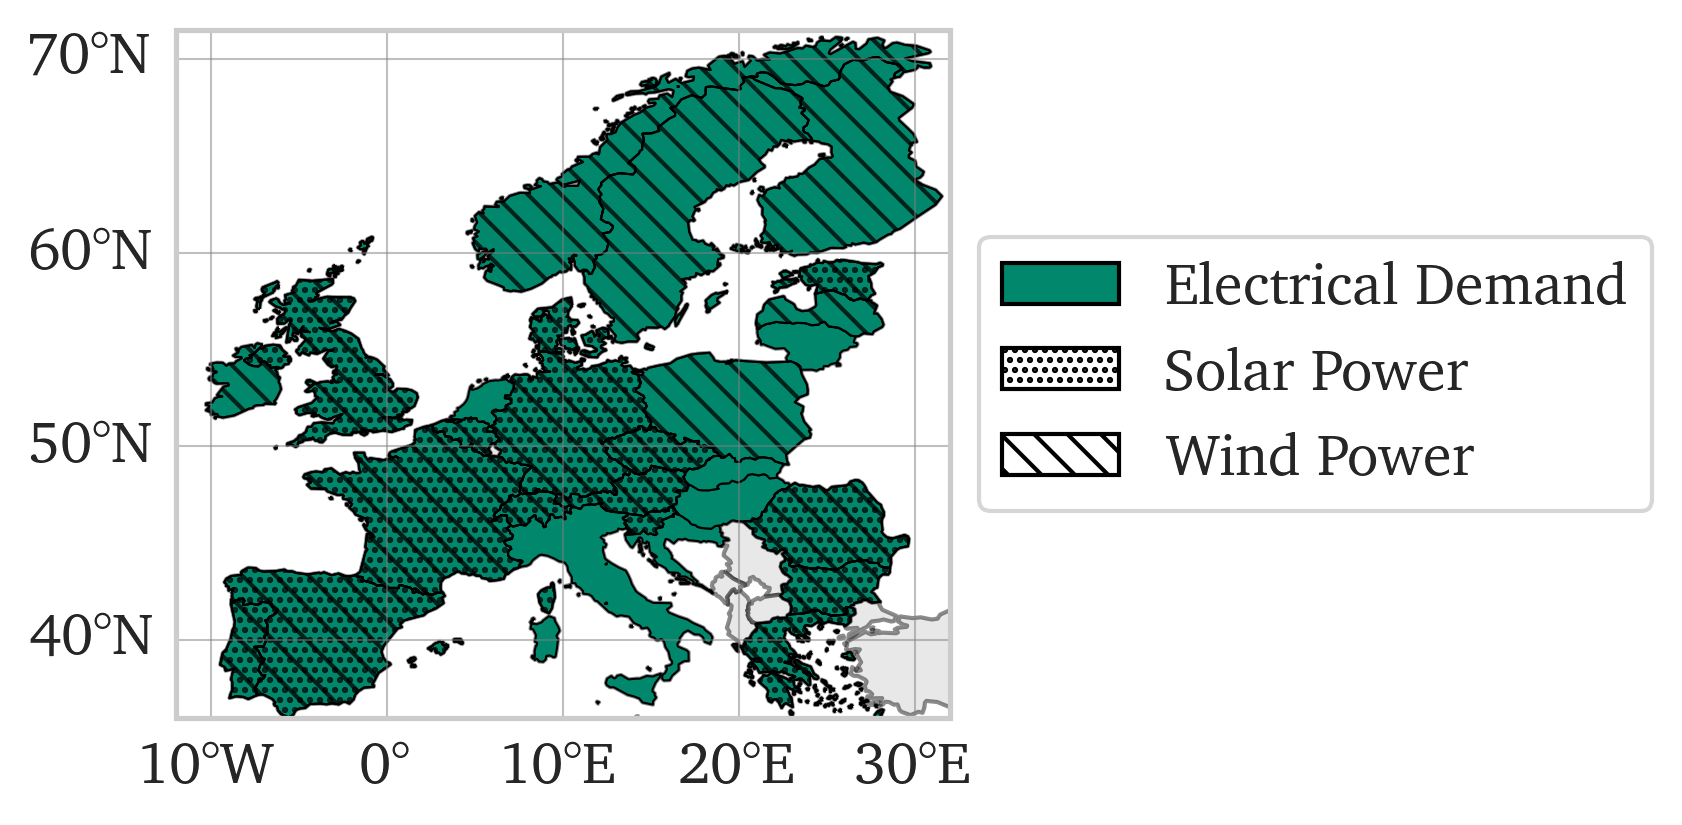

In [4]:
def plot_combined_countries(eu_countries):
    nuts_level = 0
    map_df = gpd.read_file(f'https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_20M_2016_4326_LEVL_{nuts_level}.geojson')
    map_df['id'] = map_df.NUTS_ID.apply(lambda s: s.lower())
    map_df = map_df.set_index('id')
    
    # Mapping für Farben und Schraffuren
    fill_colors = {
        'electrical_demand': '#00876C'  # "Load" wird grün gefüllt
    }
    hatches = {
        'solar_power': '.....',
        'wind_power': '\\\\\\',
    }
    
    # Cartopy-Achse mit Projektion
    fig, ax = plt.subplots(figsize=(6, 3),
                           subplot_kw={'projection': ccrs.PlateCarree()})

    # Hintergrundkarte für Europa
    map_df.plot(ax=ax, color='lightgrey', edgecolor='k', alpha=0.5)

    # Plotten von Ländern basierend auf Energiezielen
    for energy_target, countries in eu_countries.items():
        mapped_countries = [mapping[x] if x in mapping else x for x in countries]
        
        if energy_target in fill_colors:
            # Färbung für "Load"
            map_df.loc[mapped_countries].plot(
                ax=ax, edgecolor='black', facecolor=fill_colors[energy_target], 
                linewidth=0.5, label=energy_target
            )
        elif energy_target in hatches:
            # Schraffuren für "Solar" und "Wind"
            map_df.loc[mapped_countries].plot(
                ax=ax, edgecolor='black', facecolor='none', alpha=0.75,
                hatch=hatches[energy_target], linewidth=0.5, label=energy_target
            )

    # Legende erstellen
    legend_elements = [
        Patch(facecolor=fill_colors['electrical_demand'], edgecolor='black', label='Electrical Demand'),
        Patch(facecolor='none', edgecolor='black', hatch=hatches['solar_power'], label='Solar Power'),
        Patch(facecolor='none', edgecolor='black', hatch=hatches['wind_power'], label='Wind Power')
    ]
    ax.legend(handles=legend_elements,
              loc='center left', bbox_to_anchor=(1.0, 0.5))

    # Hinzufügen der Gridlines mit Ticks
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                      linewidth=0.5, color='gray',
                      alpha=0.5, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = FixedLocator(np.arange(-180, 180, 10))
    gl.ylocator = FixedLocator(np.arange(-90, 90, 10))

    # Achsenbegrenzungen setzen
    ax.set_xlim(-12, 32)
    ax.set_ylim(36, 71.5)

    # Achsentitel
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    plt.tight_layout(pad=1.0, rect=[0.05, 0.01, 0.95, 0.99])
    plt.savefig('eu_regions.png')
    plt.savefig('eu_regions.pdf')
    plt.show()
    plt.close()

# Beispiel-Daten
mapping = {
    'gb': 'uk',
    'gr': 'el'
}

countries = {
    'electrical_demand': eu_countries['load'],
    'solar_power': eu_countries['solar'],
    'wind_power': eu_countries['wind_onshore']
}

plot_combined_countries(countries)


/srv/oneumann/miniconda/envs/nwp/lib/python3.11/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.29.0
  warnings.warn(


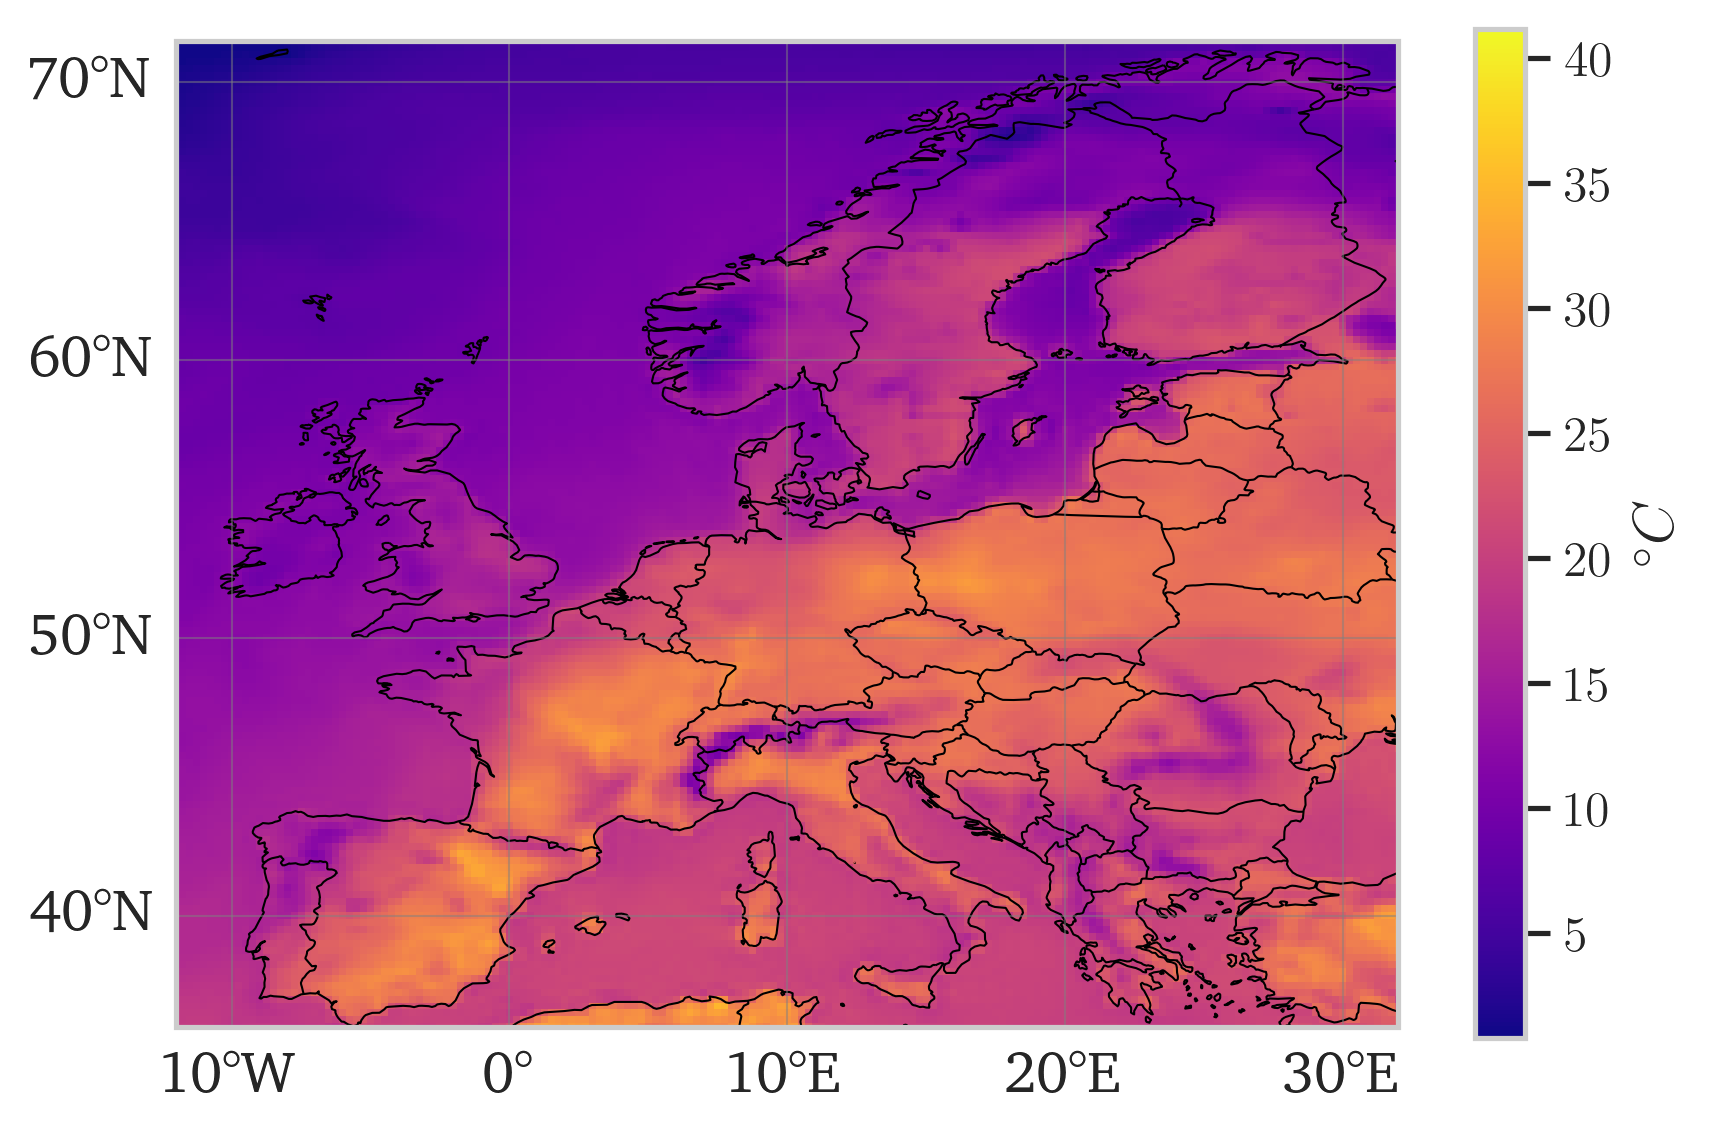

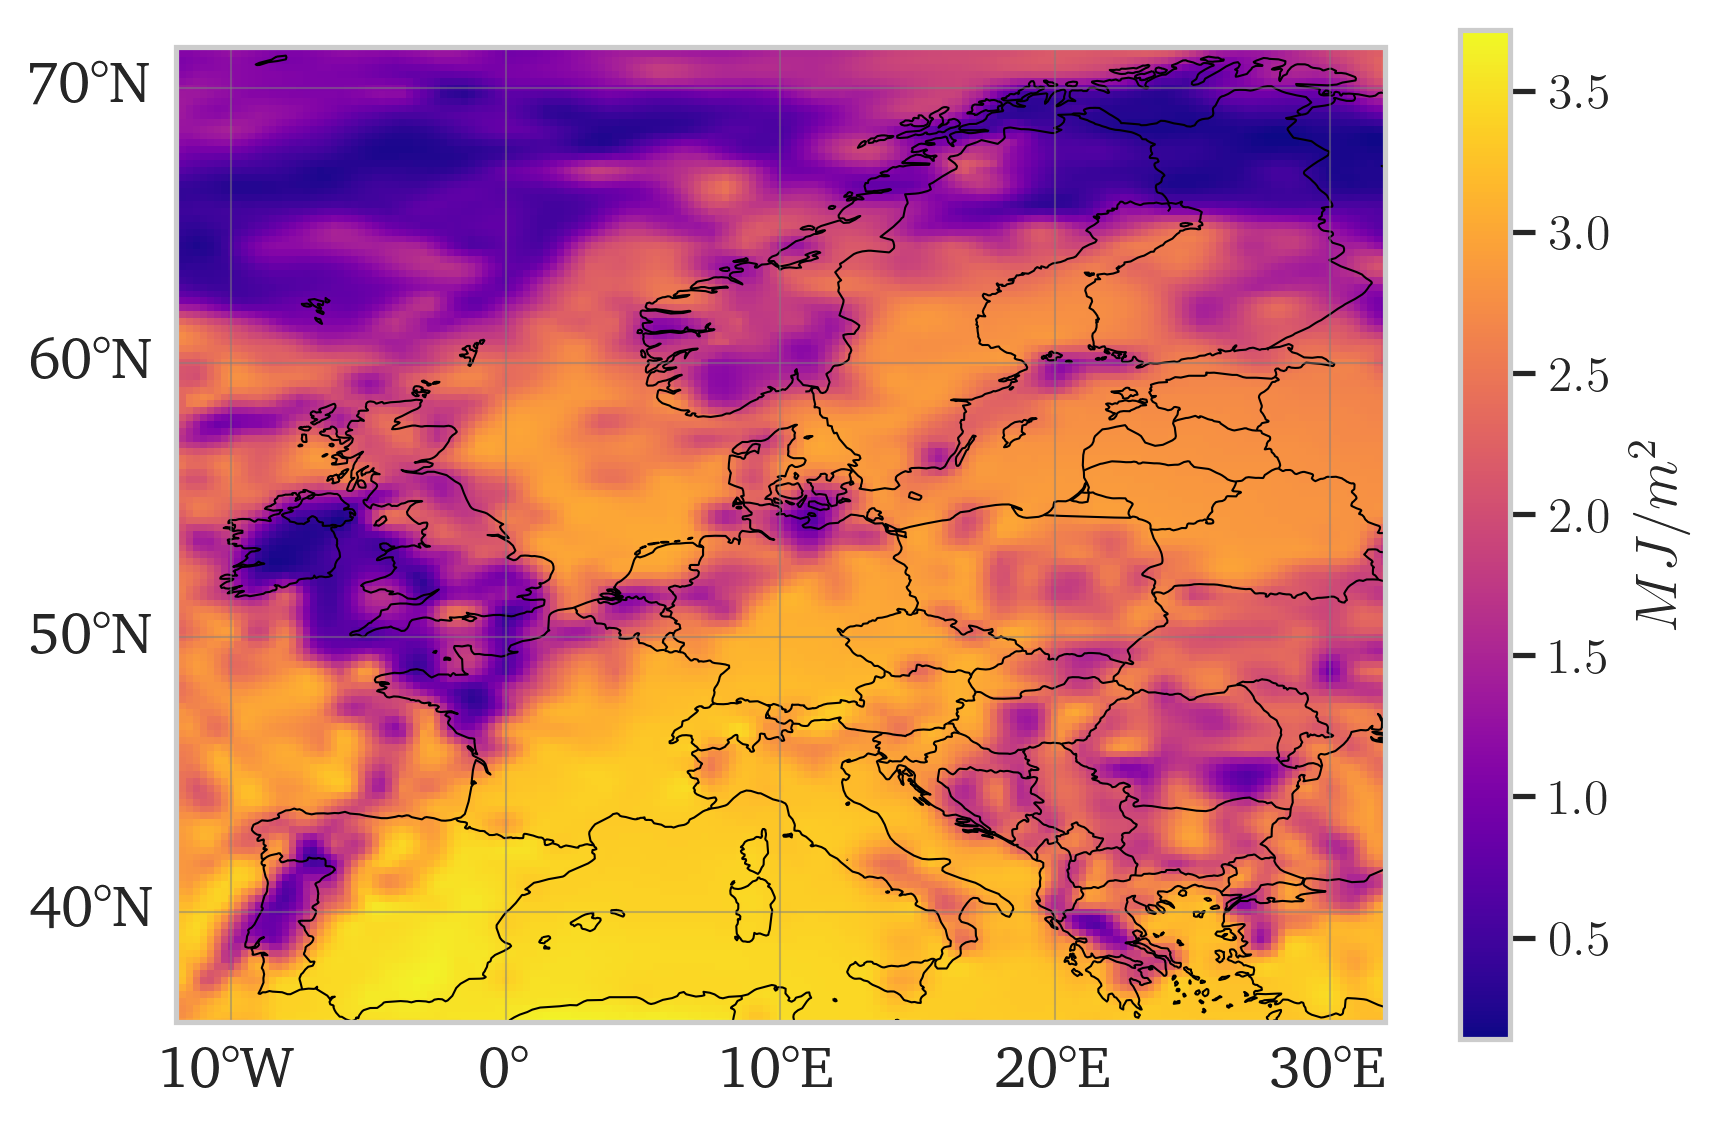

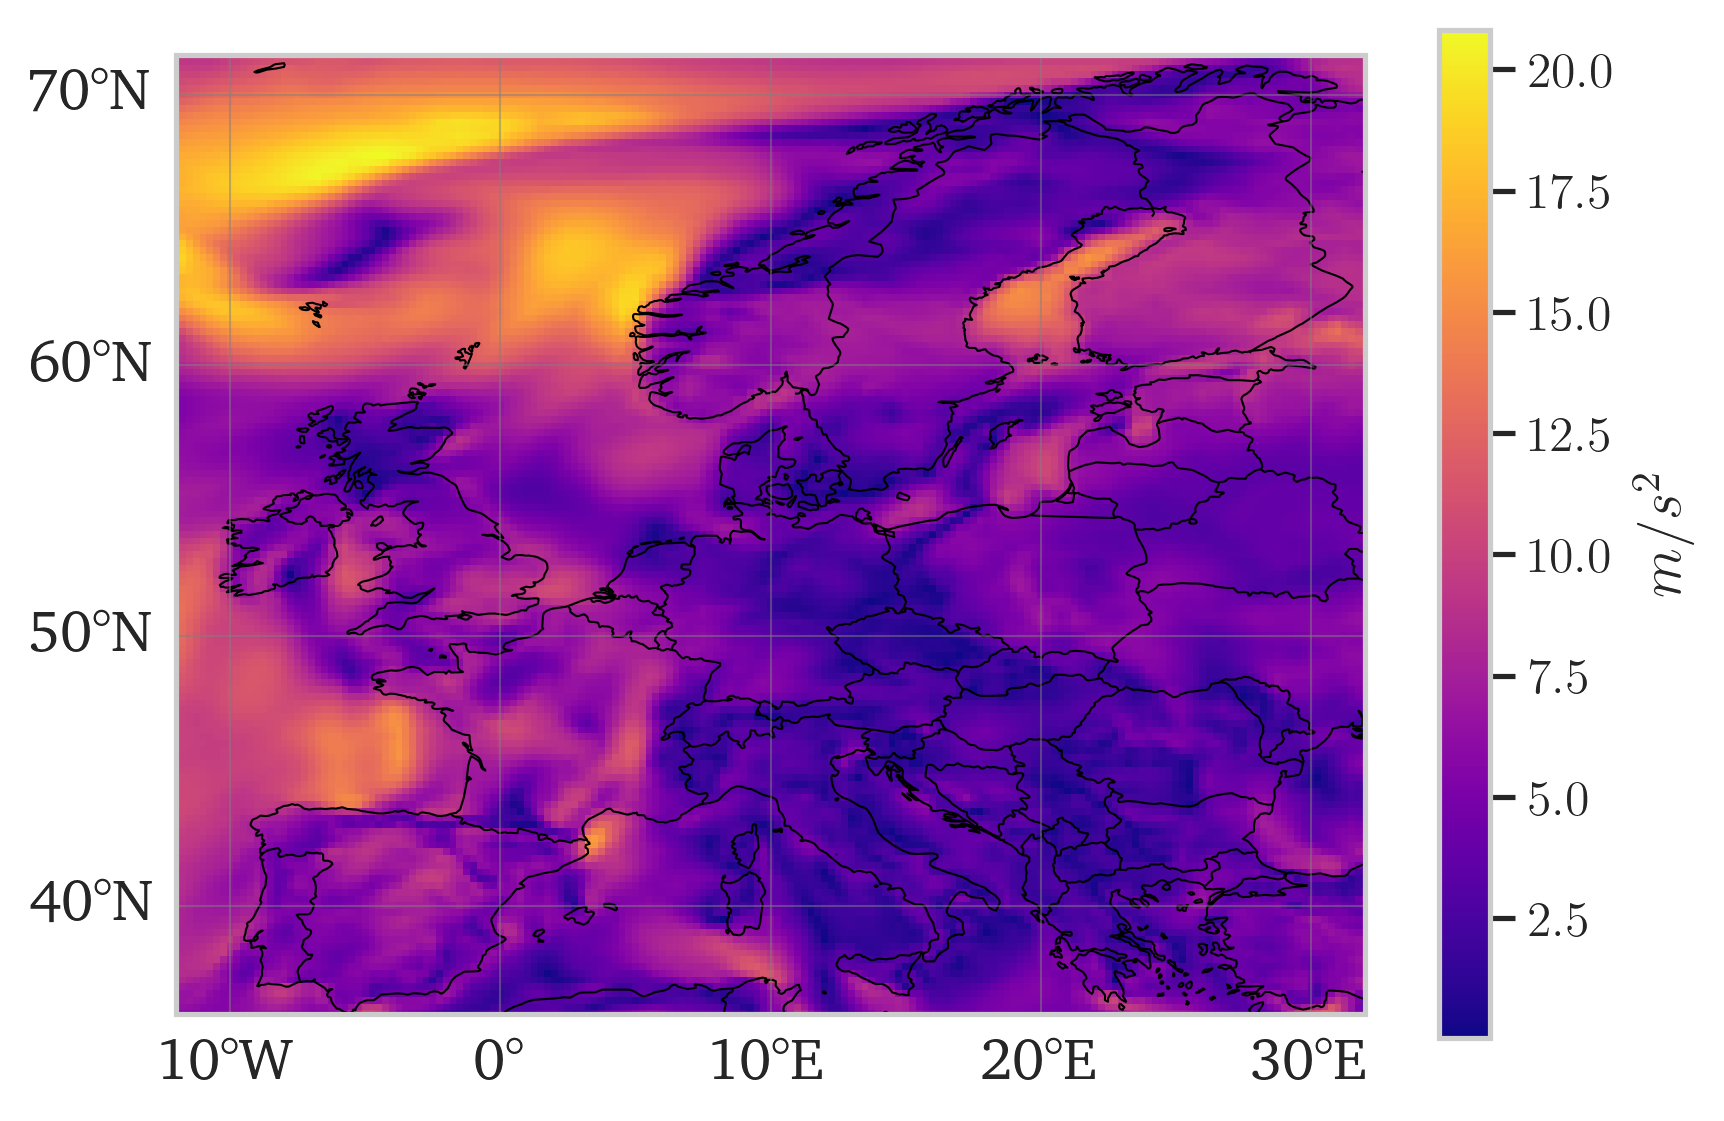

In [5]:
def plot_weather_data(weather_da, unit, filename):
    fig = plt.figure(figsize=(6, 4), dpi=300)
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    # ax.add_feature(cfeature.LAND)
    # ax.add_feature(cfeature.OCEAN)
    # ax.add_feature(cfeature.LAKES)
    # ax.add_feature(cfeature.RIVERS)

    p = weather_da.plot(
        cmap=plt.cm.plasma,
        vmin=weather_da.min().item(),
        vmax=weather_da.max().item(),
        transform=ccrs.PlateCarree(),
        cbar_kwargs={
            'shrink': 1.0,
            'label': unit
        }
    )

    # Hinzufügen der Gridlines mit Ticks
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                      linewidth=0.5, color='gray',
                      alpha=0.5, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = FixedLocator(np.arange(-180, 180, 10))
    gl.ylocator = FixedLocator(np.arange(-90, 90, 10))

    # Achsenbegrenzungen setzen
    ax.set_title('')
    ax.set_xlim(-12, 32)
    ax.set_ylim(36, 71.5)

    plt.tight_layout()
    plt.savefig(f'{filename}.png')
    plt.savefig(f'{filename}.pdf')
    plt.show()
    plt.close()


ds = xr.open_mfdataset('era5_25/*.h5', engine='h5netcdf', chunks=dict(time=1))
weather_da = ds.t2m.sel(time='2019-06-04 12:00').load()
plot_weather_data(weather_da - 273.15, '$^\circ C$', 'temperature')
weather_da = ds.ssrd.sel(time='2019-06-04 12:00').load()
plot_weather_data(weather_da / 1000 ** 2, '$MJ/m^2$', 'solar')
weather_da = np.sqrt(ds.u100.sel(time='2019-06-04 12:00').load() ** 2 + ds.v100.sel(time='2019-06-04 12:00').load() ** 2)
plot_weather_data(weather_da, '$m/s^2$', 'wind')
